# Deep Learning from Scratch with NumPy
## E-commerce Customer Recommendation - bài tập mở rộng theo notebook mẫu

Dataset `Womens Clothing E-Commerce Reviews.csv`; mục tiêu `Recommended IND` (0/1). Văn bản `Title + Review Text` được biến thành TF-IDF rồi nén bằng TruncatedSVD để tạo đầu vào dense cho MLP NumPy.

Kiến trúc 5 tầng:
$$X(B,d)\to H_1(B,128)\to H_2(B,64)\to H_3(B,32)\to H_4(B,16)\to Z(B,1)\to\sigma(Z)$$

Notebook không dùng `Rating` trong mô hình chính vì rating được ghi cùng thời điểm và quá gần nhãn recommendation, dễ tạo leakage nghiệp vụ.

## 1. Import và cấu hình

In [1]:
from pathlib import Path
import copy, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
SEED = 42
rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid")
HERE = Path.cwd()
DATA_DIR = HERE / "upload" if (HERE / "upload").exists() else HERE
MODEL_DIR = HERE / "models"
MODEL_DIR.mkdir(exist_ok=True)

# True: chạy nhanh để học/thử. False: dùng cấu hình báo cáo cuối.
FAST_MODE = True
print("FAST_MODE =", FAST_MODE)

FAST_MODE = True


## 2. Load và kiểm tra dữ liệu

In [2]:
df=pd.read_csv(DATA_DIR/"Womens Clothing E-Commerce Reviews.csv")
print("Shape:",df.shape); display(df.head()); df.info(); display(df.describe(include="all").T)
display(df.isna().sum().to_frame("missing")); print("Duplicates:",df.duplicated().sum())
display(df["Recommended IND"].value_counts().to_frame("count"))

Shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,NaN,NaN,NaN,11742.5,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliment...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


Duplicates: 0


,count
Recommended IND,
1,19314
0,4172


## 3. Làm sạch và định nghĩa representation

- Ghép `Title` và `Review Text`, chuẩn hóa chữ thường/khoảng trắng; bỏ dòng không còn text.
- Metadata: Age, Positive Feedback Count, Division/Department/Class.
- TF-IDF giữ unigram/bigram; SVD học projection từ train để chuyển sparse $B\times V$ thành dense $B\times k$.
- Sau đó ghép metadata: $X\in\mathbb{R}^{B\times d}$.
- `Clothing ID` và `Rating` không dùng để tránh ghi nhớ sản phẩm và target leakage nghiệp vụ.

In [3]:
def clean(s): return __import__('re').sub(r"\s+"," ","" if pd.isna(s) else str(s).lower()).strip()
df=df.drop(columns=["Unnamed: 0"],errors="ignore").drop_duplicates().copy()
df["text"]=(df["Title"].map(clean)+" "+df["Review Text"].map(clean)).str.strip()
df=df[(df.text.str.len()>0) & df["Recommended IND"].isin([0,1])].copy()
print("Clean shape:",df.shape); display(df[["text","Age","Department Name","Recommended IND"]].head())

Clean shape: (22641, 11)


,text,Age,Department Name,Recommended IND
0,absolutely wonderful - silky and sexy and comf...,33,Intimate,1
1,love this dress! it's sooo pretty. i happened ...,34,Dresses,1
2,some major design flaws i had such high hopes ...,60,Dresses,0
3,"my favorite buy! i love, love, love this jumps...",50,Bottoms,1
4,flattering shirt this shirt is very flattering...,47,Tops,1


## 4. Text → tokens → IDs → TF-IDF/SVD vector

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
demo=CountVectorizer(max_features=60,token_pattern=r"(?u)\b\w+\b").fit([df.text.iloc[0]])
tokens=demo.build_analyzer()(df.text.iloc[0]); ids=[demo.vocabulary_.get(t,-1) for t in tokens]
print("Text:",df.text.iloc[0][:300]); print("Tokens:",tokens[:25]); print("Token IDs:",ids[:25])
print("ID chỉ là index vocabulary, không phải mức độ ý nghĩa. SVD vector là learned low-dimensional representation.")

Text: absolutely wonderful - silky and sexy and comfortable
Tokens: ['absolutely', 'wonderful', 'silky', 'and', 'sexy', 'and', 'comfortable']
Token IDs: [np.int64(0), np.int64(5), np.int64(4), np.int64(1), np.int64(3), np.int64(1), np.int64(2)]
ID chỉ là index vocabulary, không phải mức độ ý nghĩa. SVD vector là learned low-dimensional representation.


## 5. EDA: Observation → Interpretation → ML implication

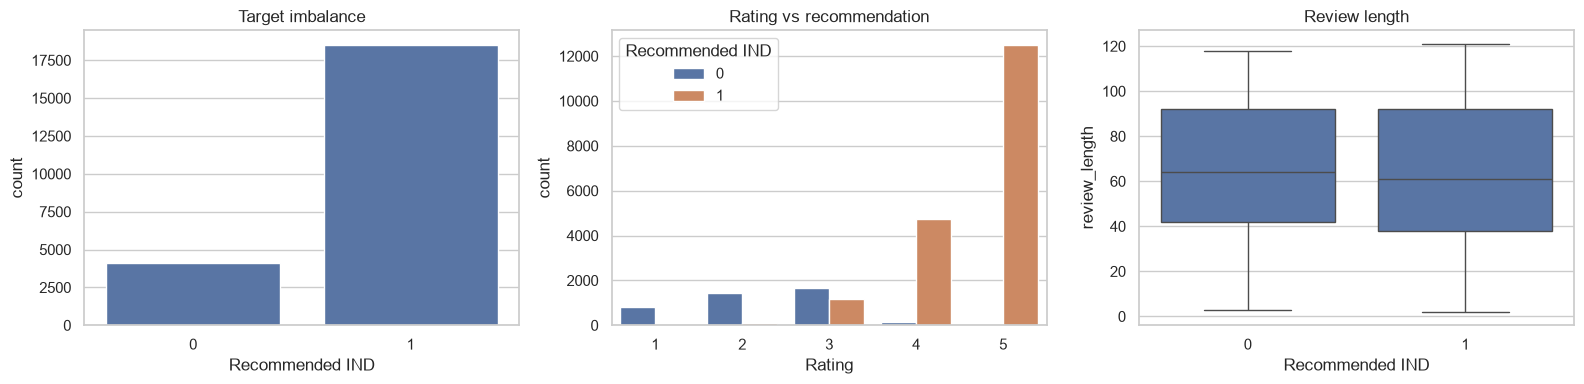

Observation: class 1 chiếm đa số; rating liên hệ rất mạnh với nhãn.
Interpretation: review chứa tín hiệu hài lòng; rating là proxy gần như trực tiếp.
ML implication: stratify, class weights, macro-F1/ROC-AUC; loại rating khỏi input chính.


In [5]:
eda=df.assign(review_length=df.text.str.split().str.len())
fig,ax=plt.subplots(1,3,figsize=(16,4))
sns.countplot(data=eda,x="Recommended IND",ax=ax[0]); ax[0].set_title("Target imbalance")
sns.countplot(data=eda,x="Rating",hue="Recommended IND",ax=ax[1]); ax[1].set_title("Rating vs recommendation")
sns.boxplot(data=eda,x="Recommended IND",y="review_length",showfliers=False,ax=ax[2]); ax[2].set_title("Review length")
plt.tight_layout(); plt.show()
print("Observation: class 1 chiếm đa số; rating liên hệ rất mạnh với nhãn.")
print("Interpretation: review chứa tín hiệu hài lòng; rating là proxy gần như trực tiếp.")
print("ML implication: stratify, class weights, macro-F1/ROC-AUC; loại rating khỏi input chính.")

## 6. Chia 70/15/15 và fit representation chỉ trên train

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix

idx=np.arange(len(df)); y=df["Recommended IND"].to_numpy(np.float32).reshape(-1,1)
itr,itmp=train_test_split(idx,test_size=.30,stratify=y.ravel(),random_state=SEED)
iv,ite=train_test_split(itmp,test_size=.50,stratify=y[itmp].ravel(),random_state=SEED)
if FAST_MODE and len(itr)>12000: itr,_=train_test_split(itr,train_size=12000,stratify=y[itr].ravel(),random_state=SEED)

tfidf=TfidfVectorizer(stop_words="english",max_features=3000,ngram_range=(1,2),min_df=3,sublinear_tf=True)
Ttr=tfidf.fit_transform(df.text.iloc[itr]); Tv=tfidf.transform(df.text.iloc[iv]); Tte=tfidf.transform(df.text.iloc[ite])
svd=TruncatedSVD(n_components=96,random_state=SEED); Str=svd.fit_transform(Ttr); Sv=svd.transform(Tv); Ste=svd.transform(Tte)
num_cols=["Age","Positive Feedback Count"]; cat_cols=["Division Name","Department Name","Class Name"]
num_imp=SimpleImputer(strategy="median"); scaler=StandardScaler(); cat_imp=SimpleImputer(strategy="most_frequent"); onehot=OneHotEncoder(handle_unknown="ignore",sparse_output=False)
Ntr=scaler.fit_transform(num_imp.fit_transform(df.iloc[itr][num_cols])); Nv=scaler.transform(num_imp.transform(df.iloc[iv][num_cols])); Nte=scaler.transform(num_imp.transform(df.iloc[ite][num_cols]))
Ctr=onehot.fit_transform(cat_imp.fit_transform(df.iloc[itr][cat_cols])); Cv=onehot.transform(cat_imp.transform(df.iloc[iv][cat_cols])); Cte=onehot.transform(cat_imp.transform(df.iloc[ite][cat_cols]))
Xtr=np.hstack([Str,Ntr,Ctr]).astype(np.float32); Xv=np.hstack([Sv,Nv,Cv]).astype(np.float32); Xte=np.hstack([Ste,Nte,Cte]).astype(np.float32)
ytr,yv,yte=y[itr],y[iv],y[ite]
print("Raw TF-IDF:",Ttr.shape,"SVD:",Str.shape,"Final:",Xtr.shape,Xv.shape,Xte.shape)
print("SVD explained variance:",round(float(svd.explained_variance_ratio_.sum()),4))

Raw TF-IDF: (12000, 3000) SVD: (12000, 96) Final: (12000, 127) (3396, 127) (3397, 127)
SVD explained variance: 0.2157


## 7. Cài đặt MLP 5 tầng, BCE, backpropagation và Adam bằng NumPy

In [7]:
def relu(x): return np.maximum(x,0)
def relu_grad(x): return (x>0).astype(np.float32)
def sigmoid(x): return 1/(1+np.exp(-np.clip(x,-30,30)))

def init_mlp(dims,seed=42):
    r=np.random.default_rng(seed); p={}
    for i,(din,dout) in enumerate(zip(dims[:-1],dims[1:]),1):
        p[f"W{i}"]=(r.standard_normal((din,dout))*np.sqrt(2/din)).astype(np.float32)
        p[f"b{i}"]=np.zeros((1,dout),np.float32)
    return p

def forward_cls(X,p,return_hidden=False):
    A=X; cache=[]; L=len(p)//2
    for i in range(1,L):
        Z=A@p[f"W{i}"]+p[f"b{i}"]; cache.append((A,Z)); A=relu(Z)
    logits=A@p[f"W{L}"]+p[f"b{L}"]; cache.append((A,logits)); prob=sigmoid(logits)
    hidden=[relu(v[1]) for v in cache[:-1]]
    return (prob,cache,hidden) if return_hidden else (prob,cache)

def bce(y,p,w0=1,w1=1):
    p=np.clip(p,1e-7,1-1e-7); w=np.where(y==1,w1,w0)
    return float(np.mean(w*(-y*np.log(p)-(1-y)*np.log(1-p))))

def backward_cls(prob,y,p,cache,w0=1,w1=1):
    L=len(p)//2; n=len(y); w=np.where(y==1,w1,w0); dZ=w*(prob-y)/n; g={}
    for i in range(L,0,-1):
        Aprev,Z=cache[i-1]; g[f"W{i}"]=Aprev.T@dZ; g[f"b{i}"]=dZ.sum(0,keepdims=True)
        if i>1: dZ=(dZ@p[f"W{i}"].T)*relu_grad(cache[i-2][1])
    return g

def adam_step(p,g,s,t,lr=1e-3,clip=5):
    norm=np.sqrt(sum(float((v*v).sum()) for v in g.values())); scale=min(1.,clip/(norm+1e-12))
    for k in p:
        q=g[k]*scale; s['m'][k]=.9*s['m'][k]+.1*q; s['v'][k]=.999*s['v'][k]+.001*q*q
        p[k]-=lr*(s['m'][k]/(1-.9**t))/(np.sqrt(s['v'][k]/(1-.999**t))+1e-8)

def train_classifier(Xtr,ytr,Xv,yv,dims,lr=1e-3,epochs=20,batch=128,weighted=True,patience=6,seed=42):
    p=init_mlp(dims,seed); s={'m':{k:np.zeros_like(v) for k,v in p.items()},'v':{k:np.zeros_like(v) for k,v in p.items()}}
    n0=(ytr==0).sum(); n1=(ytr==1).sum(); w0=len(ytr)/(2*n0) if weighted else 1; w1=len(ytr)/(2*n1) if weighted else 1
    hist={'train':[],'val':[]}; best=(np.inf,None,0); step=0; r=np.random.default_rng(seed)
    for ep in range(epochs):
        for idx in np.array_split(r.permutation(len(Xtr)),max(1,int(np.ceil(len(Xtr)/batch)))):
            prob,c=forward_cls(Xtr[idx],p); g=backward_cls(prob,ytr[idx],p,c,w0,w1); step+=1; adam_step(p,g,s,step,lr)
        tl=bce(ytr,forward_cls(Xtr,p)[0],w0,w1); vl=bce(yv,forward_cls(Xv,p)[0],w0,w1)
        hist['train'].append(tl); hist['val'].append(vl)
        if vl<best[0]-1e-5: best=(vl,copy.deepcopy(p),ep+1)
        elif ep+1-best[2]>=patience: break
    return best[1],hist,best[2]

## 8. Exercise 1 - chạy mô hình 5 tầng

In [8]:
d=Xtr.shape[1]; dims=[d,128,64,32,16,1]; epochs=12 if FAST_MODE else 30
t0=time.time(); params,hist,best_epoch=train_classifier(Xtr,ytr,Xv,yv,dims,lr=.001,epochs=epochs,batch=256,weighted=True)
print("Architecture:",dims,"best epoch:",best_epoch,"time(s):",round(time.time()-t0,2))

Architecture: [127, 128, 64, 32, 16, 1] best epoch: 9 time(s): 1.81


## 9. Training curves và overfitting

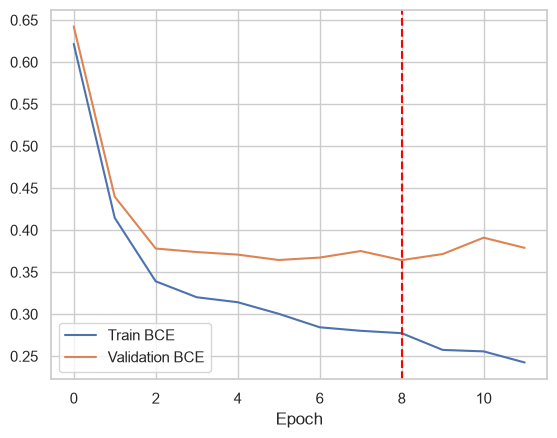

Validation loss tăng trong khi train loss giảm là dấu hiệu overfitting; checkpoint tốt nhất đã được giữ.


In [9]:
plt.plot(hist['train'],label='Train BCE'); plt.plot(hist['val'],label='Validation BCE'); plt.axvline(best_epoch-1,color='red',ls='--'); plt.legend(); plt.xlabel('Epoch'); plt.show()
print("Validation loss tăng trong khi train loss giảm là dấu hiệu overfitting; checkpoint tốt nhất đã được giữ.")

## 10. Đánh giá validation và test

In [10]:
def evaluate(y,prob,threshold=.5):
    pred=(prob.ravel()>=threshold).astype(int); yy=y.ravel().astype(int)
    return {"Accuracy":accuracy_score(yy,pred),"Precision":precision_score(yy,pred,zero_division=0),"Recall":recall_score(yy,pred,zero_division=0),"F1":f1_score(yy,pred,zero_division=0),"Macro F1":f1_score(yy,pred,average='macro'),"ROC-AUC":roc_auc_score(yy,prob.ravel())},pred
val_prob=forward_cls(Xv,params)[0]; test_prob=forward_cls(Xte,params)[0]
vm,_=evaluate(yv,val_prob); tm,test_pred=evaluate(yte,test_prob)
display(pd.DataFrame([vm,tm],index=['Validation','Test']).round(4)); display(pd.DataFrame(confusion_matrix(yte.ravel(),test_pred),index=['Actual 0','Actual 1'],columns=['Pred 0','Pred 1']))
print("Actual 0 → Pred 1 là review không khuyến nghị bị bỏ sót; cần theo dõi recall của lớp 0 và macro-F1.")

,Accuracy,Precision,Recall,F1,Macro F1,ROC-AUC
Validation,0.8230,0.9710,0.8080,0.8820,0.7639,0.9198
Test,0.8084,0.9667,0.7933,0.8715,0.7475,0.9086


,Pred 0,Pred 1
Actual 0,539,76
Actual 1,575,2207


Actual 0 → Pred 1 là review không khuyến nghị bị bỏ sót; cần theo dõi recall của lớp 0 và macro-F1.


## 11. Exercise 2 - thay đổi learning rate

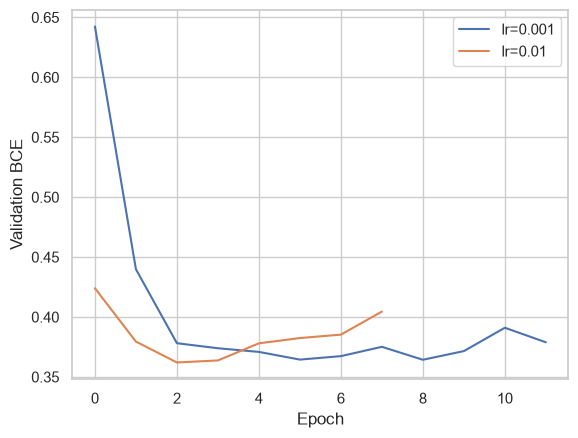

In [11]:
lr_runs={.001:hist}
for lr in [.01]:
    _,h,_=train_classifier(Xtr,ytr,Xv,yv,dims,lr=lr,epochs=8 if FAST_MODE else 30,batch=256,weighted=True)
    lr_runs[lr]=h
for lr,h in lr_runs.items(): plt.plot(h['val'],label=f'lr={lr}')
plt.xlabel('Epoch'); plt.ylabel('Validation BCE'); plt.legend(); plt.show()

## 12. Exercise 3 - class weights và decision threshold

In [12]:
p_unweighted,h_unweighted,_=train_classifier(Xtr,ytr,Xv,yv,dims,lr=.001,epochs=8 if FAST_MODE else 30,batch=256,weighted=False)
for t in [.3,.5,.7]:
    m,_=evaluate(yv,val_prob,t); print(f"threshold={t}: Precision={m['Precision']:.4f}, Recall={m['Recall']:.4f}, MacroF1={m['Macro F1']:.4f}")
mw,_=evaluate(yv,val_prob); mu,_=evaluate(yv,forward_cls(Xv,p_unweighted)[0])
display(pd.DataFrame([mw,mu],index=['Weighted BCE','Unweighted BCE']).round(4))

threshold=0.3: Precision=0.9523, Recall=0.8688, MacroF1=0.7894
threshold=0.5: Precision=0.9710, Recall=0.8080, MacroF1=0.7639
threshold=0.7: Precision=0.9815, Recall=0.7249, MacroF1=0.7118


,Accuracy,Precision,Recall,F1,Macro F1,ROC-AUC
Weighted BCE,0.8230,0.9710,0.8080,0.8820,0.7639,0.9198
Unweighted BCE,0.8863,0.9088,0.9572,0.9324,0.7878,0.9205


## 13. Exercise 4 - inspect learned representations

In [13]:
_,_,hidden=forward_cls(Xtr[:256],params,return_hidden=True)
for i,H in enumerate(hidden,1): print(f"H{i}.shape =",H.shape,"zero fraction =",round(float((H==0).mean()),3))

H1.shape = (256, 128) zero fraction = 0.431
H2.shape = (256, 64) zero fraction = 0.304
H3.shape = (256, 32) zero fraction = 0.363
H4.shape = (256, 16) zero fraction = 0.276


## 14. Baseline TF-IDF Logistic Regression và đối sánh

In [16]:
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# =========================================================
# 1. Logistic Regression dùng trực tiếp TF-IDF sparse
# =========================================================

Ztr = hstack([
    Ttr,
    csr_matrix(Ntr),
    csr_matrix(Ctr)
])

Zte = hstack([
    Tte,
    csr_matrix(Nte),
    csr_matrix(Cte)
])

logistic_model = LogisticRegression(
    max_iter=1500,
    class_weight="balanced"
)

logistic_model.fit(
    Ztr,
    ytr.ravel().astype(int)
)

logistic_probability = logistic_model.predict_proba(Zte)[:, 1]

logistic_metrics, _ = evaluate(
    yte,
    logistic_probability
)

# =========================================================
# 2. Decision Tree và Random Forest dùng đầu vào SVD
#    giống đầu vào của MLP
# =========================================================

tree_models = {
    "Decision Tree SVD": DecisionTreeClassifier(
        max_depth=18,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=SEED
    ),

    "Random Forest SVD": RandomForestClassifier(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=3,
        n_jobs=-1,
        class_weight="balanced",
        random_state=SEED
    )
}

# Kết quả của MLP và Logistic Regression
rows = [
    {
        "Model": "Deep MLP 5-layer",
        **tm
    },
    {
        "Model": "TF-IDF Logistic Regression",
        **logistic_metrics
    }
]

# Huấn luyện hai mô hình cây
for name, model in tree_models.items():
    model.fit(
        Xtr,
        ytr.ravel().astype(int)
    )

    probability = model.predict_proba(Xte)[:, 1]

    model_metrics, _ = evaluate(
        yte,
        probability
    )

    rows.append({
        "Model": name,
        **model_metrics
    })

# Macro-F1 càng cao càng tốt
comparison = (
    pd.DataFrame(rows)
    .sort_values("Macro F1", ascending=False)
    .set_index("Model")
)

display(comparison.round(4))

print(
    "Đối sánh MLP 5 tầng với TF-IDF Logistic Regression, "
    "Decision Tree SVD và Random Forest SVD."
)

,Accuracy,Precision,Recall,F1,Macro F1,ROC-AUC
Model,,,,,,
TF-IDF Logistic Regression,0.8705,0.9632,0.8753,0.9171,0.8103,0.9367
Random Forest SVD,0.8646,0.9126,0.9231,0.9178,0.7669,0.8938
Deep MLP 5-layer,0.8084,0.9667,0.7933,0.8715,0.7475,0.9086
Decision Tree SVD,0.7604,0.8880,0.8095,0.8469,0.6477,0.6939


Đối sánh MLP 5 tầng với TF-IDF Logistic Regression, Decision Tree SVD và Random Forest SVD.


## 15. Lưu model và toàn bộ representation pipeline

In [15]:
artifact={"tfidf":tfidf,"svd":svd,"num_imputer":num_imp,"scaler":scaler,"cat_imputer":cat_imp,"onehot":onehot,"params":params,"architecture":dims,"features":{"numeric":num_cols,"categorical":cat_cols},"threshold":.5}
path=MODEL_DIR/"numpy_mlp_5layers_ecommerce.joblib"; joblib.dump(artifact,path); print("Saved:",path)

Saved: C:\Users\hhai6\models\numpy_mlp_5layers_ecommerce.joblib


## Tổng kết cần trình bày trong báo cáo

1. Nêu rõ review → tokens/IDs → TF-IDF $B\times V$ → SVD $B\times96$ → ghép metadata → MLP.
2. Giải thích từng tensor shape và learned representation $H_1...H_4$.
3. Phân tích class imbalance, weighted BCE, threshold trade-off và overfitting.
4. Báo cáo Accuracy, Precision, Recall, F1, Macro-F1, ROC-AUC và confusion matrix.
5. Đối sánh MLP với Logistic Regression bằng kết quả chạy thật; không chép số trong PDF mẫu.
6. Nêu giới hạn: dataset là review tiếng Anh, không có lịch sử định danh khách hàng; recommendation là nhãn tự khai báo.